In [14]:
# cleanup and fix isogeometric plate case
# first let's plot the basis functions from _plate.py
import numpy as np

# 1) make the open knot vector
nxe, p = 7, 4
# nxe, p = 4, 1
knots = [0.0]*(p+1) + [i/nxe for i in range(1,nxe)] + [1.0]*(p+1)
print(f"{knots=}")
n_ctrl = nxe + p # number of control ponts

# 2) find span to determine where in vector to do interpolations
def find_span(n_ctrl, degree, u, U):
    # Cox-de Boor span search (n_ctrl = number of control points)
    if u >= U[-1] - 1e-12:
        return n_ctrl - 1
    low = degree
    high = len(U)-degree-1
    mid = (low+high)//2
    while True:
        if u < U[mid]:
            high = mid
        elif u >= U[mid+1]:
            low = mid
        else:
            return mid
        mid = (low+high)//2

# get basis functions

def basis_functions_and_derivatives(span, u, degree, U, n_deriv=1):
    # Compute nonzero basis functions and first derivatives using Cox-de Boor + derivative formula
    # Returns arrays N[0:degree] and dN[0:degree]
    left = np.zeros(degree+1)
    right = np.zeros(degree+1)
    ndu = np.zeros((degree+1, degree+1))
    ndu[0,0] = 1.0
    for j in range(1, degree+1):
        left[j] = u - U[span+1-j]
        right[j] = U[span+j] - u
        saved = 0.0
        for r in range(j):
            ndu[j,r] = right[r+1] + left[j-r]
            temp = ndu[r,j-1]/ndu[j,r]
            ndu[r,j] = saved + right[r+1]*temp
            saved = left[j-r]*temp
        ndu[j,j] = saved
    N = ndu[:,degree].copy()
    # derivatives
    ders = np.zeros((n_deriv+1, degree+1))
    a = np.zeros((2, degree+1))
    # compute a triangular table of derivatives
    for r in range(degree+1):
        s1 = 0; s2 = 1
        a[0,0] = 1.0
        for k in range(1, n_deriv+1):
            d = 0.0
            rk = r - k
            pk = degree - k
            if r >= k:
                a[s2,0] = a[s1,0]/ndu[pk+1,rk]
                d = a[s2,0]*ndu[rk,pk]
            j1 = 1 if rk >= -1 else -rk
            j2 = k-1 if r-1 <= pk else degree - r
            for j in range(j1, j2+1):
                a[s2,j] = (a[s1,j] - a[s1,j-1]) / ndu[pk+1, rk+j]
                d += a[s2,j]*ndu[rk+j, pk]
            if r <= pk:
                a[s2,k] = -a[s1,k-1]/ndu[pk+1, r]
                d += a[s2,k]*ndu[r, pk]
            ders[k,r] = d
            s1, s2 = s2, s1
    # Multiply by correct factors
    for k in range(1, n_deriv+1):
        for j in range(degree+1):
            ders[k,j] *= degree
    return N, ders[1]

knots=[0.0, 0.0, 0.0, 0.0, 0.0, 0.14285714285714285, 0.2857142857142857, 0.42857142857142855, 0.5714285714285714, 0.7142857142857143, 0.8571428571428571, 1.0, 1.0, 1.0, 1.0, 1.0]


ndegen_knots=[0.0, 0.14285714285714285, 0.2857142857142857, 0.42857142857142855, 0.5714285714285714, 0.7142857142857143, 0.8571428571428571, 1.0]


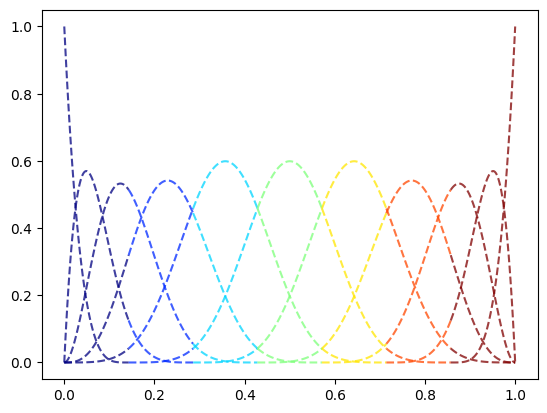

In [15]:
# now plot each separate basis function in the span?
import matplotlib.pyplot as plt

ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe))
# linestyles = ['-', '--', '-.', ':']

ndegen_knots = knots[p:(nxe+1+p)]
print(f"{ndegen_knots=}")
for i in range(len(ndegen_knots)-1):
    knot1 = ndegen_knots[i]; knot2 = ndegen_knots[i+1]
    # print(f"{knot1=} {knot2=}")
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 100)
        span = find_span(n_ctrl, p, np.mean(uvec), knots)  # gets starting index?
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _u in enumerate(uvec):
            N, deriv = basis_functions_and_derivatives(span, _u, p, knots, n_deriv=1)
            Nvals[:,ii] = N[:]

        for iN in range(p+1):
            rand_scale = 0.0
            # rand_scale = 0.05
            plt.plot(uvec, Nvals[iN,:] + np.random.rand(1)*rand_scale, linestyle='--', color=colors[ielem], alpha=0.75)
        
        ielem += 1
plt.show()


ndegen_knots=[0.0, 0.14285714285714285, 0.2857142857142857, 0.42857142857142855, 0.5714285714285714, 0.7142857142857143, 0.8571428571428571, 1.0]


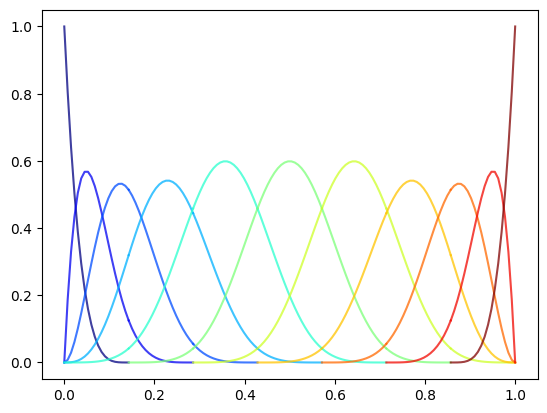

In [16]:
"""
plot it again with the colors of each basis fcn
"""
import matplotlib.pyplot as plt

ielem = 0
colors = plt.cm.jet(np.linspace(0.0, 1.0, nxe + p))
linestyles = ['-', '--', '-.', ':']

ndegen_knots = knots[p:(nxe+1+p)]
print(f"{ndegen_knots=}")
for i in range(len(ndegen_knots)-1):
    knot1 = ndegen_knots[i]; knot2 = ndegen_knots[i+1]
    # print(f"{knot1=} {knot2=}")
    dknot = knot2 - knot1
    if abs(dknot) > 1e-12:
        uvec = np.linspace(knot1, knot2, 20)
        span = find_span(n_ctrl, p, np.mean(uvec), knots)  # gets starting index?
        Nvals = np.zeros((p+1, uvec.shape[0]))
        for ii, _u in enumerate(uvec):
            N, deriv = basis_functions_and_derivatives(span, _u, p, knots, n_deriv=1)
            Nvals[:,ii] = N[:]

        for iN in range(p+1):
            rand_scale = 0.0
            # rand_scale = 0.05
            icolor = ielem + iN
            plt.plot(
                uvec, 
                Nvals[iN,:] + np.random.rand(1)*rand_scale, 
                # linestyle=linestyles[iN],
                linestyle='-', 
                color=colors[icolor], 
                alpha=0.75
            )
        
        ielem += 1
plt.show()

In [17]:
from math import comb
import numpy as np

np.set_printoptions(threshold=np.inf, linewidth=200, suppress=True)

def quartic_bernstein(xi):
    xi = np.asarray(xi)
    B = np.array([
        comb(4,0) * (1-xi)**4,
        comb(4,1) * xi*(1-xi)**3,
        comb(4,2) * xi**2*(1-xi)**2,
        comb(4,3) * xi**3*(1-xi),
        comb(4,4) * xi**4,
    ])
    return B

def compute_quartic_extraction_mats(knots, nxe, find_span, basis_functions_and_derivatives, nsamp=40):
    p = 4
    n_ctrl = nxe + p
    Ce_list = []

    for ielem in range(nxe):
        u1 = knots[p + ielem]
        u2 = knots[p + ielem + 1]

        # sample points strictly inside element
        xis = np.linspace(0.0, 1.0, nsamp, endpoint=False) + 0.5/nsamp
        us = u1 + (u2 - u1) * xis

        B = quartic_bernstein(xis).T     # (nsamp, 5)
        Nvals = np.zeros((nsamp, 5))     # active spline values on this element

        for k, u in enumerate(us):
            span = find_span(n_ctrl, p, u, knots)
            N, _ = basis_functions_and_derivatives(span, u, p, knots, n_deriv=1)
            Nvals[k, :] = N

        # Solve B @ C^T = Nvals
        Ct, *_ = np.linalg.lstsq(B, Nvals, rcond=None)
        Ce = Ct.T
        Ce_list.append(Ce)

    return Ce_list

Ce_list = compute_quartic_extraction_mats(knots, nxe, find_span, basis_functions_and_derivatives)

names = ["first", "second", "third"] + \
        [f"interior_{i}" for i in range(3, nxe-3)] + \
        ["third_last", "second_last", "last"]

for name, Ce in zip(names, Ce_list):
    print(f"\n{name}:")
    print(np.round(Ce, 12))

import numpy as np

def write_matrix_clean(f, name, Ce):
    f.write(f"\n{name}:\n")
    for row in Ce:
        row_str = ", ".join(f"{v:.12f}" for v in row)
        f.write(f"[{row_str}]\n")

with open("quartic_extraction.txt", "w") as f:
    for i, Ce in enumerate(Ce_list):
        if i == 0:
            name = "first"
        elif i == 1:
            name = "second"
        elif i == 2:
            name = "third"
        elif i == nxe - 3:
            name = "third_last"
        elif i == nxe - 2:
            name = "second_last"
        elif i == nxe - 1:
            name = "last"
        else:
            name = f"interior_{i}"

        write_matrix_clean(f, name, Ce)

print("wrote quartic_extraction.txt")


first:
[[ 1.          0.          0.         -0.         -0.        ]
 [ 0.          1.          0.5         0.25        0.125     ]
 [-0.         -0.          0.5         0.58333333  0.51388889]
 [ 0.         -0.          0.          0.16666667  0.31944444]
 [-0.         -0.          0.          0.          0.04166667]]

second:
[[ 0.125       0.          0.          0.         -0.        ]
 [ 0.51388889  0.44444444  0.22222222  0.11111111  0.05555556]
 [ 0.31944444  0.47222222  0.61111111  0.55555556  0.44444444]
 [ 0.04166667  0.08333333  0.16666667  0.33333333  0.45833333]
 [ 0.         -0.          0.         -0.          0.04166667]]

third:
[[ 0.05555556 -0.          0.         -0.         -0.        ]
 [ 0.44444444  0.33333333  0.16666667  0.08333333  0.04166667]
 [ 0.45833333  0.58333333  0.66666667  0.58333333  0.45833333]
 [ 0.04166667  0.08333333  0.16666667  0.33333333  0.45833333]
 [ 0.         -0.          0.          0.          0.04166667]]

interior_3:
[[ 0.04166667 

nxe=7 p=4 nglob=11


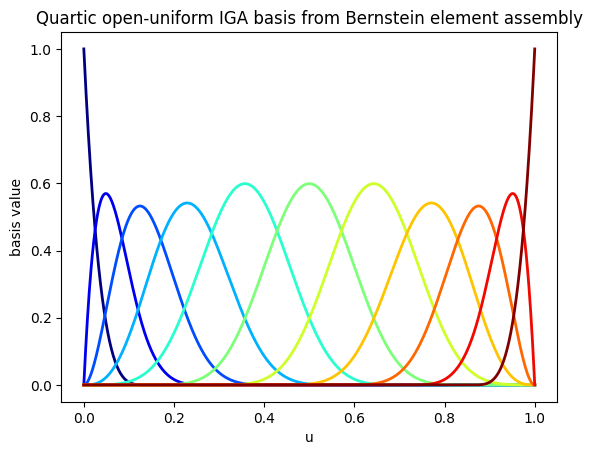

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# quartic Bernstein basis
# -------------------------------------------------
def quartic_bernstein(xi):
    N = np.array([
        (1 - xi)**4,
        4*xi*(1 - xi)**3,
        6*xi**2*(1 - xi)**2,
        4*xi**3*(1 - xi),
        xi**4
    ])
    dN = np.array([
        -4*(1 - xi)**3,
        4*(1 - xi)**3 - 12*xi*(1 - xi)**2,
        12*xi*(1 - xi)**2 - 12*xi**2*(1 - xi),
        12*xi**2*(1 - xi) - 4*xi**3,
        4*xi**3
    ])
    return N, dN


# -------------------------------------------------
# setup
# -------------------------------------------------
nxe, p = 7, 4
knots = [0.0]*(p+1) + [i/nxe for i in range(1, nxe)] + [1.0]*(p+1)

u = np.linspace(0.0, 1.0, 1000)
nglob = nxe + p
print(f"{nxe=} {p=} {nglob=}")

global_basis = np.zeros((nglob, u.shape[0]))

# local basis to global basis connectivities
elem_conn = [
    [i, i+1, i+2, i+3, i+4] for i in range(nxe)
]

# -------------------------------------------------
# assemble global quartic IGA basis
# -------------------------------------------------
for ielem in range(nxe):
    knot1, knot2 = knots[p + ielem], knots[p + ielem + 1]

    # normalized local coordinate
    xi = (u - knot1) / (knot2 - knot1)
    xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)

    # quartic Bernstein basis
    B, dB = quartic_bernstein(xi)

    first_elem   = (ielem == 0)
    second_elem  = (ielem == 1)
    third_elem   = (ielem == 2)

    third_last   = (ielem == nxe - 3)
    second_last  = (ielem == nxe - 2)
    last_elem    = (ielem == nxe - 1)

    interior = not (first_elem or second_elem or third_elem or
                    third_last or second_last or last_elem)

    if first_elem:
        N0 = 1.0 * B[0]
        N1 = 1.0 * B[1] + 0.5 * B[2] + 0.25 * B[3] + 0.125 * B[4]
        N2 = 0.5 * B[2] + (7.0/12.0) * B[3] + (37.0/72.0) * B[4]
        N3 = (1.0/6.0) * B[3] + (23.0/72.0) * B[4]
        N4 = (1.0/24.0) * B[4]

    elif second_elem:
        N0 = (1.0/8.0) * B[0]
        N1 = (37.0/72.0)*B[0] + (4.0/9.0)*B[1] + (2.0/9.0)*B[2] \
           + (1.0/9.0)*B[3] + (1.0/18.0)*B[4]
        N2 = (23.0/72.0)*B[0] + (17.0/36.0)*B[1] + (11.0/18.0)*B[2] \
           + (5.0/9.0)*B[3] + (4.0/9.0)*B[4]
        N3 = (1.0/24.0)*B[0] + (1.0/12.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/3.0)*B[3] + (11.0/24.0)*B[4]
        N4 = (1.0/24.0) * B[4]

    elif third_elem:
        N0 = (1.0/18.0) * B[0]
        N1 = (4.0/9.0)*B[0] + (1.0/3.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/12.0)*B[3] + (1.0/24.0)*B[4]
        N2 = (11.0/24.0)*B[0] + (7.0/12.0)*B[1] + (2.0/3.0)*B[2] \
           + (7.0/12.0)*B[3] + (11.0/24.0)*B[4]
        N3 = (1.0/24.0)*B[0] + (1.0/12.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/3.0)*B[3] + (11.0/24.0)*B[4]
        N4 = (1.0/24.0) * B[4]

    elif third_last:
        # mirror of third
        N0 = (1.0/24.0) * B[0]
        N1 = (11.0/24.0)*B[0] + (1.0/3.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/12.0)*B[3] + (1.0/24.0)*B[4]
        N2 = (11.0/24.0)*B[0] + (7.0/12.0)*B[1] + (2.0/3.0)*B[2] \
           + (7.0/12.0)*B[3] + (11.0/24.0)*B[4]
        N3 = (1.0/24.0)*B[0] + (1.0/12.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/3.0)*B[3] + (4.0/9.0)*B[4]
        N4 = (1.0/18.0) * B[4]

    elif second_last:
        # mirror of second
        N0 = (1.0/24.0) * B[0]
        N1 = (11.0/24.0)*B[0] + (1.0/3.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/12.0)*B[3] + (1.0/24.0)*B[4]
        N2 = (4.0/9.0)*B[0] + (5.0/9.0)*B[1] + (11.0/18.0)*B[2] \
           + (17.0/36.0)*B[3] + (23.0/72.0)*B[4]
        N3 = (1.0/18.0)*B[0] + (1.0/9.0)*B[1] + (2.0/9.0)*B[2] \
           + (4.0/9.0)*B[3] + (37.0/72.0)*B[4]
        N4 = (1.0/8.0) * B[4]

    elif last_elem:
        # mirror of first
        N0 = (1.0/24.0) * B[0]
        N1 = (23.0/72.0) * B[0] + (1.0/6.0) * B[1]
        N2 = (37.0/72.0) * B[0] + (7.0/12.0) * B[1] + 0.5 * B[2]
        N3 = 0.125 * B[0] + 0.25 * B[1] + 0.5 * B[2] + 1.0 * B[3]
        N4 = 1.0 * B[4]

    else:  # interior
        N0 = (1.0/24.0) * B[0]
        N1 = (11.0/24.0)*B[0] + (1.0/3.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/12.0)*B[3] + (1.0/24.0)*B[4]
        N2 = (11.0/24.0)*B[0] + (7.0/12.0)*B[1] + (2.0/3.0)*B[2] \
           + (7.0/12.0)*B[3] + (11.0/24.0)*B[4]
        N3 = (1.0/24.0)*B[0] + (1.0/12.0)*B[1] + (1.0/6.0)*B[2] \
           + (1.0/3.0)*B[3] + (11.0/24.0)*B[4]
        N4 = (1.0/24.0) * B[4]

    # add into global basis
    g0, g1, g2, g3, g4 = elem_conn[ielem]
    global_basis[g0] += N0 * xi_mask
    global_basis[g1] += N1 * xi_mask
    global_basis[g2] += N2 * xi_mask
    global_basis[g3] += N3 * xi_mask
    global_basis[g4] += N4 * xi_mask


# -------------------------------------------------
# plot
# -------------------------------------------------
colors = plt.cm.jet(np.linspace(0.0, 1.0, nglob))
for iglob in range(nglob):
    plt.plot(u, global_basis[iglob], color=colors[iglob], lw=2)

plt.xlabel("u")
plt.ylabel("basis value")
plt.title("Quartic open-uniform IGA basis from Bernstein element assembly")
plt.show()